In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('superstore.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (9800, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Postal Code', 'Country', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Country,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2021-1000,2021-08-17,2021-08-19,Standard Class,CG-65302,Customer 17,Corporate,Colorado City,Colorado,...,United States,West,Prod-2535,Furniture,Furnishings,Eldon Fold N Roll Cart System,69.02,1,0.2,40.92
1,2,CA-2021-1001,2022-03-24,2022-03-27,Standard Class,CG-10851,Customer 389,Home Office,Georgia City,Georgia,...,United States,South,Prod-7924,Office Supplies,Binders,Ibico Hi-Tech Manual Binding System,1336.29,5,0.1,898.78
2,3,CA-2021-1002,2022-11-28,2022-12-02,Same Day,CG-89131,Customer 136,Consumer,New York City,New York,...,United States,East,Prod-8527,Office Supplies,Art,Sanford Canvas Sketch Pad,27.58,1,0.0,22.30
3,4,CA-2021-1003,2021-09-13,2021-09-18,Standard Class,CG-19116,Customer 24,Home Office,Texas City,Texas,...,United States,South,Prod-4733,Technology,Accessories,Belkin USB-C Hub,116.68,5,0.4,58.47
4,5,CA-2021-1004,2022-08-16,2022-08-18,First Class,CG-56566,Customer 108,Consumer,Tennessee City,Tennessee,...,United States,South,Prod-5374,Office Supplies,Fasteners,Stockwell Rubber Bands by Alliance,14.40,3,0.1,9.86


In [3]:
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Stats:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   City           9800 non-null   object 
 9   State          9800 non-null   object 
 10  Postal Code    9800 non-null   int64  
 11  Country        9800 non-null   object 
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9800.000000,9800.000000,9800.00000,9800.000000,9800.000000,9800.000000
mean,4900.500000,55585.492041,598.73896,2.993367,0.145776,433.616299
std,2829.160653,25847.628986,989.99022,1.403441,0.157503,742.950068
min,1.000000,10007.000000,2.40000,1.000000,0.000000,1.600000
25%,2450.750000,33014.000000,42.39750,2.000000,0.000000,30.117500
50%,4900.500000,56065.000000,161.81000,3.000000,0.100000,113.615000
75%,7350.250000,78015.500000,690.80500,4.000000,0.300000,481.037500
max,9800.000000,99974.000000,6596.15000,5.000000,0.500000,5692.960000


In [4]:
print("Total Revenue: $", round(df['Sales'].sum(), 2))
print("Total Profit: $", round(df['Profit'].sum(), 2))
print("Total Orders:", df['Order ID'].nunique())
print("Profit Margin:", round((df['Profit'].sum() / df['Sales'].sum()) * 100, 2), "%")

Total Revenue: $ 5867641.81
Total Profit: $ 4249439.73
Total Orders: 9800
Profit Margin: 72.42 %


C:\Users\phart\AppData\Local\Temp\ipykernel_20880\3633422519.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='Blues_d')


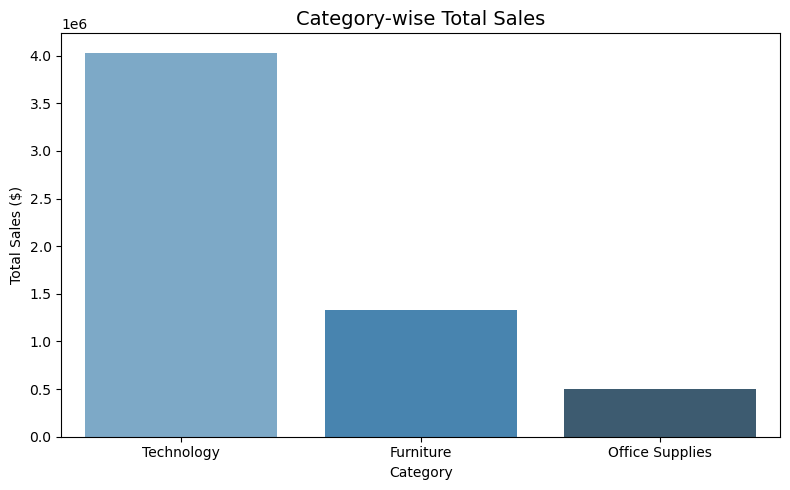

In [5]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='Blues_d')
plt.title('Category-wise Total Sales', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('category_sales.png')
plt.show()

C:\Users\phart\AppData\Local\Temp\ipykernel_20880\1429907693.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_profit.index, y=region_profit.values, palette='Greens_d')


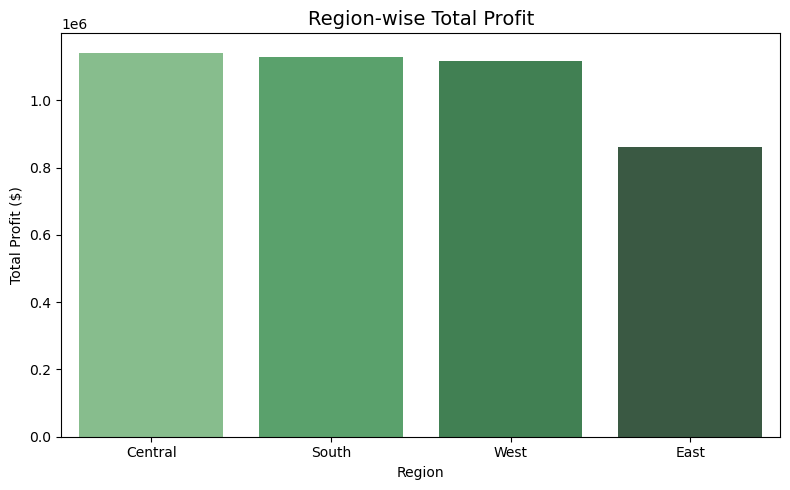

In [6]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_profit.index, y=region_profit.values, palette='Greens_d')
plt.title('Region-wise Total Profit', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('region_profit.png')
plt.show()

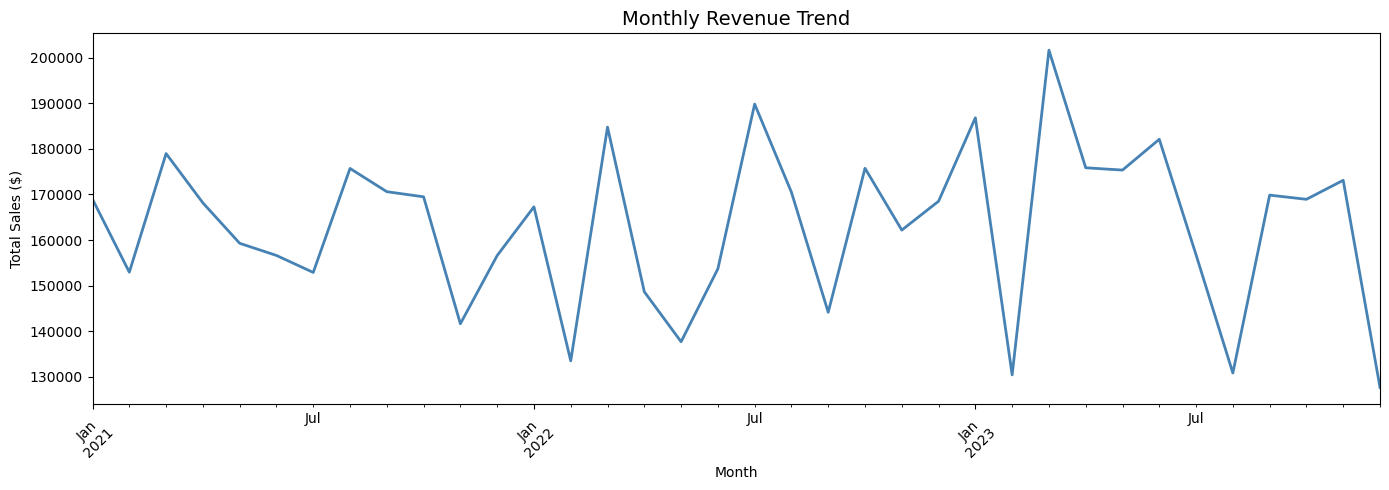

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')
monthly = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(14, 5))
monthly.plot(kind='line', color='steelblue', linewidth=2)
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()

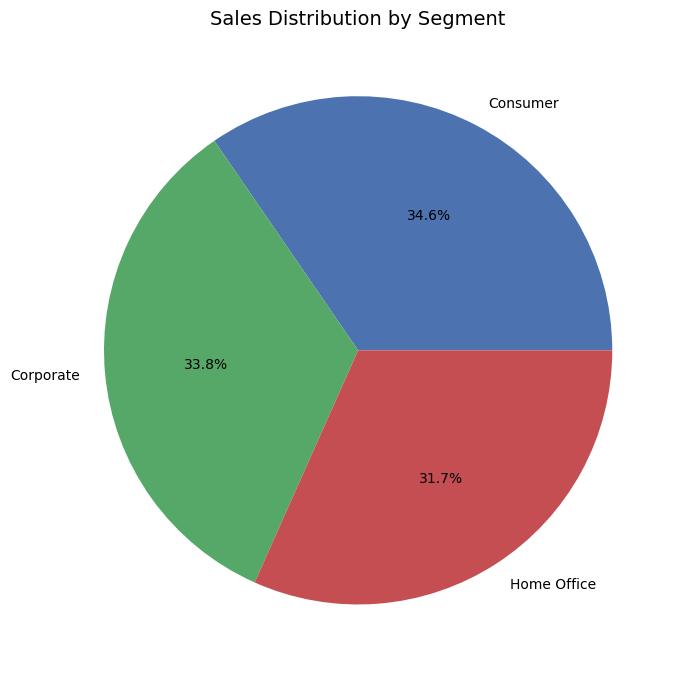

In [8]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(7, 7))
plt.pie(segment_sales.values, labels=segment_sales.index, autopct='%1.1f%%',
        colors=['#4C72B0','#55A868','#C44E52'])
plt.title('Sales Distribution by Segment', fontsize=14)
plt.tight_layout()
plt.savefig('segment_pie.png')
plt.show()

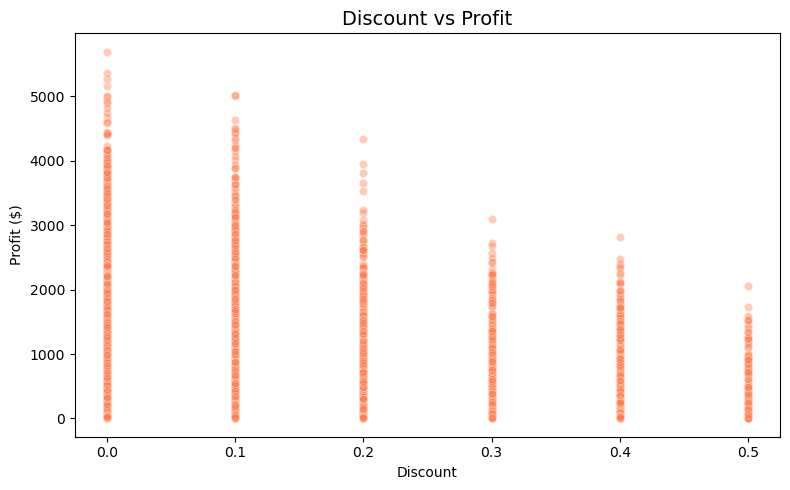

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4, color='coral')
plt.title('Discount vs Profit', fontsize=14)
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.savefig('discount_profit.png')
plt.show()

C:\Users\phart\AppData\Local\Temp\ipykernel_20880\3767752824.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='Oranges_d')


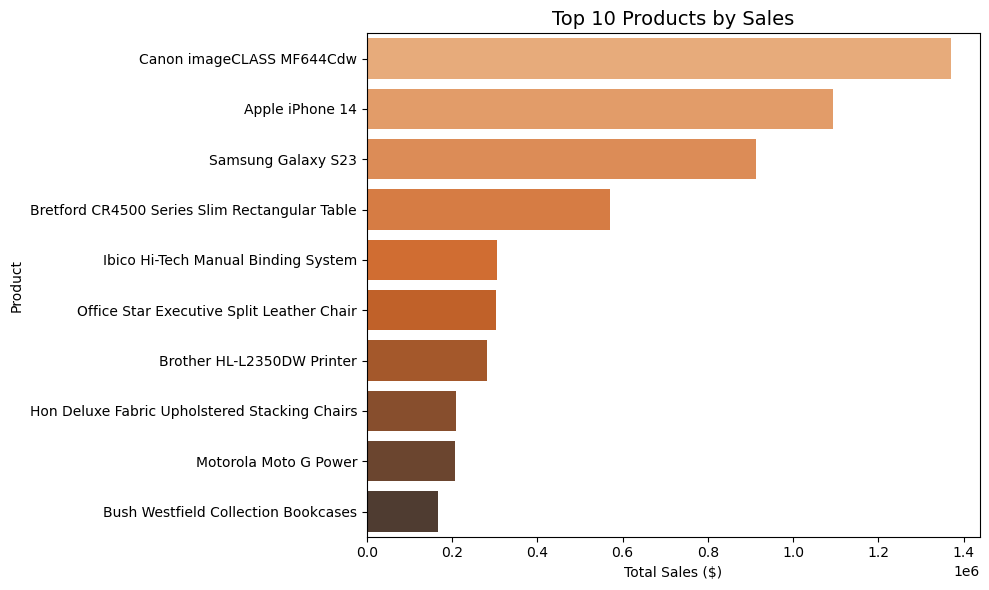

In [10]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='Oranges_d')
plt.title('Top 10 Products by Sales', fontsize=14)
plt.xlabel('Total Sales ($)')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()

In [11]:
print("=" * 50)
print("KEY BUSINESS INSIGHTS")
print("=" * 50)
print(f"1. Total Revenue: ${round(df['Sales'].sum(),2)}")
print(f"2. Overall Profit Margin: {round((df['Profit'].sum()/df['Sales'].sum())*100,2)}%")
print(f"3. Best Category: {df.groupby('Category')['Sales'].sum().idxmax()}")
print(f"4. Best Region by Profit: {df.groupby('Region')['Profit'].sum().idxmax()}")
print(f"5. Best Segment: {df.groupby('Segment')['Sales'].sum().idxmax()}")
print(f"6. High Discount (>0.3) avg profit: ${round(df[df['Discount']>0.3]['Profit'].mean(),2)}")
print(f"7. No Discount avg profit: ${round(df[df['Discount']==0]['Profit'].mean(),2)}")
print("=" * 50)

KEY BUSINESS INSIGHTS
1. Total Revenue: $5867641.81
2. Overall Profit Margin: 72.42%
3. Best Category: Technology
4. Best Region by Profit: Central
5. Best Segment: Consumer
6. High Discount (>0.3) avg profit: $232.35
7. No Discount avg profit: $527.59


In [12]:
readme = """# E-commerce Customer Behavior - Python EDA

## Project Overview
Exploratory Data Analysis on 9,800+ e-commerce orders from Superstore dataset
to uncover sales trends, profit drivers, and customer behavior patterns.

## Key Findings
- Technology category generated highest revenue
- West region had highest sales
- Consumer segment contributed maximum sales (approx 50%)
- High discounts (>30%) led to negative average profit
- No-discount orders had significantly higher profit margins

## Visualizations
- Category-wise Total Sales (Bar Chart)
- Region-wise Total Profit (Bar Chart)
- Monthly Revenue Trend (Line Chart)
- Sales Distribution by Segment (Pie Chart)
- Discount vs Profit Impact (Scatter Plot)
- Top 10 Products by Sales (Bar Chart)

## Tools Used
- Python 3
- Pandas, NumPy
- Matplotlib, Seaborn
- Jupyter Notebook
- Dataset: Superstore Sales (9,800+ records)
"""

with open('README.md', 'w') as f:
    f.write(readme)

print("README.md created!")

README.md created!
